# Analiza tekstur: GLCM i klasyfikacja

Celem tego notatnika jest praktyczne zastosowanie macierzy GLCM (Gray-Level Co-occurrence Matrix) do wyznaczenia cech teksturowych obrazów i wykorzystanie ich do klasyfikacji kilku klas tekstur z bazy **KTH-TIPS**.

## 1. Podstawy teoretyczne GLCM

Macierz GLCM (zaproponowana przez Haralicka w 1973 r.) opisuje statystykę drugiego rzędu obrazu w skali szarości: zlicza, jak często dana para poziomów szarości $(i, j)$ pojawia się dla zadanego przesunięcia — odległości $d$ i kąta $\theta$.

Dla obrazu kwantowanego do $L$ poziomów szarości GLCM ma rozmiar $L \times L$. Typowe odległości to $d \in \{1, 2, 3\}$, a kąty $\theta \in \{0°, 45°, 90°, 135°\}$ (cztery kierunki kardynalne). Macierz jest następnie normalizowana do rozkładu prawdopodobieństwa $P(i,j)$.

### Najpopularniejsze cechy Haralicka

| Cecha | Wzór | Interpretacja |
| :--- | :--- | :--- |
| **Contrast** | $\sum_{i,j} (i-j)^2 P(i,j)$ | Lokalne zmiany intensywności — tekstura szorstka vs. gładka |
| **Dissimilarity** | $\sum_{i,j} |i-j| \cdot P(i,j)$ | Podobnie jak contrast, ale liniowo |
| **Homogeneity** | $\sum_{i,j} \frac{P(i,j)}{1 + (i-j)^2}$ | Jak blisko diagonali skupione są wartości |
| **Energy (ASM)** | $\sum_{i,j} P(i,j)^2$ | Jednorodność tekstury — wysoka dla regularnych wzorów |
| **Correlation** | $\sum_{i,j} \frac{(i-\mu_i)(j-\mu_j)P(i,j)}{\sigma_i \sigma_j}$ | Liniowa zależność poziomów szarości sąsiadów |
| **Entropy** | $-\sum_{i,j} P(i,j) \log P(i,j)$ | Losowość / nieuporządkowanie tekstury |

### Przegląd bibliotek

| Biblioteka | Funkcje | Uwagi |
| :--- | :--- | :--- |
| **scikit-image** | `graycomatrix`, `graycoprops` | Standard w Pythonie. Zwraca: contrast, dissimilarity, homogeneity, ASM, energy, correlation. Entropię liczymy ręcznie. |
| **mahotas** | `haralick` | Zwraca komplet 13 cech Haralicka od razu, ale interfejs jest mniej elastyczny (brak wyboru pojedynczych kątów). |
| **OpenCV** | brak wbudowanego GLCM | Dla GLCM używamy skimage/mahotas. |

W tym notatniku używamy **scikit-image** — ma przejrzyste API, jest szeroko stosowana i pozwala łatwo dobrać parametry.

## 2. Import bibliotek i konfiguracja

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from skimage.feature import graycomatrix, graycoprops
from skimage.util import img_as_ubyte

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

RNG = 42
np.random.seed(RNG)

## 3. Wczytanie zbioru danych KTH-TIPS

Baza **KTH-TIPS** (Textures under varying Illumination, Pose and Scale) zawiera 10 klas materiałów sfotografowanych w różnej skali i oświetleniu. Każda klasa ma 81 obrazów grayscale 200×200 px.

Wybieramy **5 klas** o wyraźnie różnej strukturze powierzchni, aby zadanie klasyfikacji było sensowne:
- `aluminium_foil` — pofałdowana, błyszcząca folia
- `brown_bread` — porowata, nieregularna struktura
- `corduroy` — regularne, kierunkowe prążki
- `linen` — drobne splecenie nitek
- `sponge` — nieregularne pory o dużym kontraście

In [2]:
DATA_DIR = Path('KTH_TIPS')
CLASSES = ['aluminium_foil', 'brown_bread', 'corduroy', 'linen', 'sponge']

def load_class_images(class_name, data_dir=DATA_DIR):
    folder = data_dir / class_name
    images = []
    for p in sorted(folder.glob('*.png')):
        img = np.array(Image.open(p).convert('L'))
        images.append(img)
    return images

dataset = {c: load_class_images(c) for c in CLASSES}
for c, imgs in dataset.items():
    print(f'{c:18s}  N={len(imgs):3d}  shape={imgs[0].shape}  dtype={imgs[0].dtype}')

aluminium_foil      N= 81  shape=(200, 200)  dtype=uint8
brown_bread         N= 81  shape=(200, 200)  dtype=uint8
corduroy            N= 81  shape=(200, 200)  dtype=uint8
linen               N= 81  shape=(200, 200)  dtype=uint8
sponge              N= 81  shape=(200, 200)  dtype=uint8


### 3.1 Podgląd klas

Wyświetlmy po 3 reprezentatywne obrazy z każdej klasy, aby wizualnie ocenić różnice w strukturze.

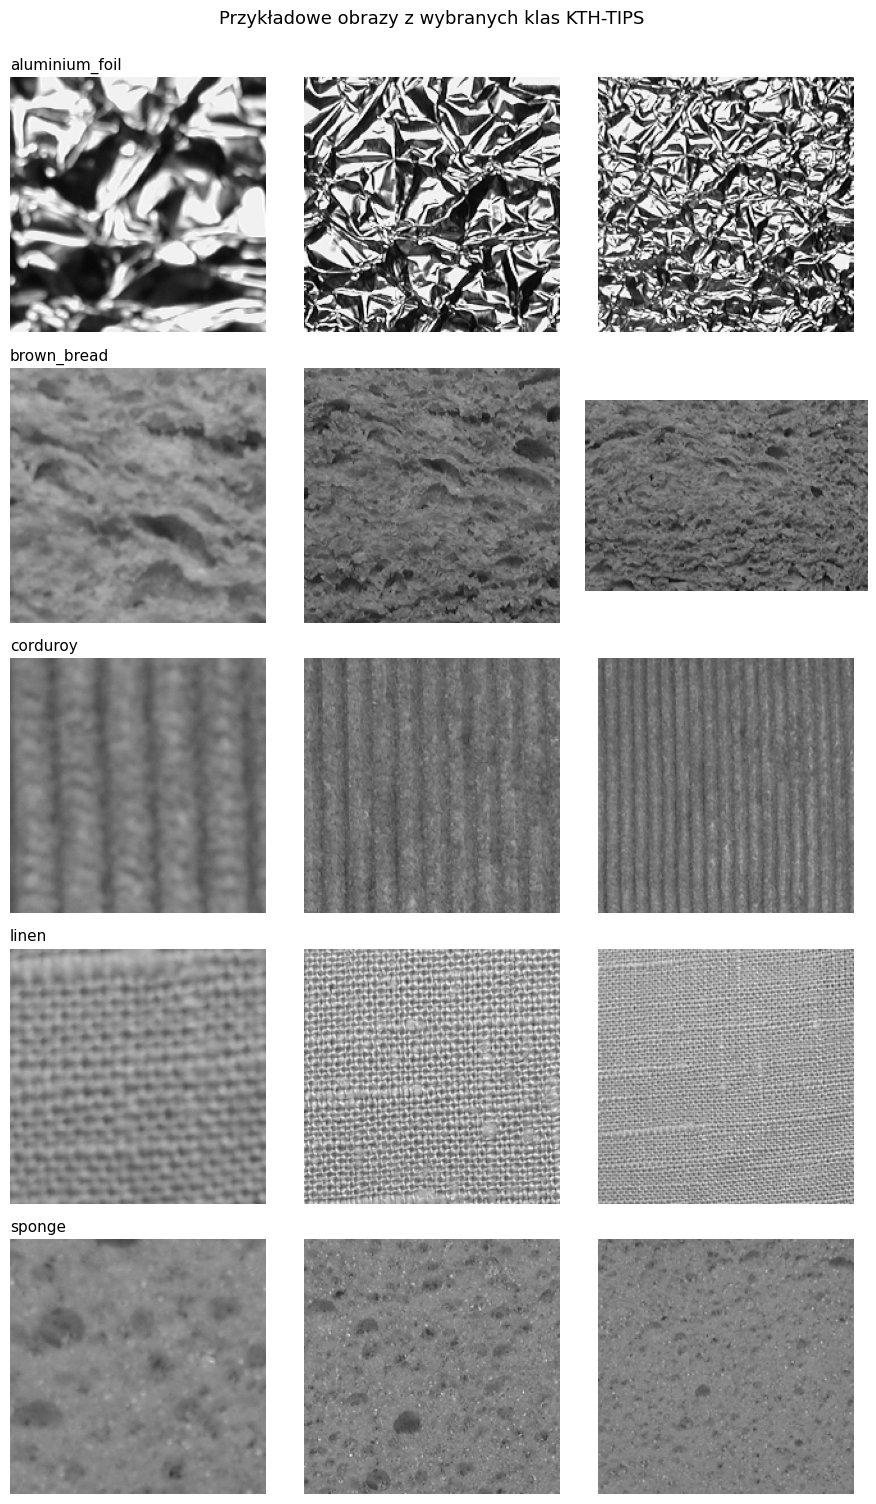

In [3]:
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 3 * len(CLASSES)))
for row, c in enumerate(CLASSES):
    samples = dataset[c][::len(dataset[c]) // 3][:3]
    for col, img in enumerate(samples):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(c, rotation=0, labelpad=55, fontsize=11, va='center')
    axes[row, 0].set_title(c, fontsize=11, loc='left')
plt.suptitle('Przykładowe obrazy z wybranych klas KTH-TIPS', fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

## 4. Obliczanie GLCM — przykład

Dla pojedynczego obrazu z każdej klasy policzmy GLCM i porównajmy wartości kilku cech. Dzięki temu zobaczymy, czy cechy różnicują klasy.

**Parametry GLCM:**
- `levels=32` — kwantyzujemy obraz do 32 poziomów szarości (mniejsza macierz 32×32, szybsze obliczenia i mniej szumu statystycznego niż przy 256 poziomach)
- `distances=[1, 3]` — sąsiedztwo bezpośrednie i o 3 piksele dalej
- `angles=[0, π/4, π/2, 3π/4]` — cztery kierunki
- `symmetric=True` — GLCM symetryczna (niezależność od kolejności par)
- `normed=True` — normalizacja do rozkładu prawdopodobieństwa

In [4]:
LEVELS = 32
DISTANCES = [1, 3]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
PROPS = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

def quantize(img, levels=LEVELS):
    # Skalujemy 0..255 do 0..levels-1
    return (img.astype(np.float32) / 256.0 * levels).astype(np.uint8)

def glcm_entropy(glcm):
    # entropia per (distance, angle), zwraca tablicę jak graycoprops
    eps = 1e-12
    p = glcm
    return -np.sum(p * np.log2(p + eps), axis=(0, 1))

# Jeden obraz z każdej klasy
example_imgs = {c: dataset[c][0] for c in CLASSES}

rows = []
for c, img in example_imgs.items():
    q = quantize(img)
    glcm = graycomatrix(q, distances=DISTANCES, angles=ANGLES,
                         levels=LEVELS, symmetric=True, normed=True)
    row = {'class': c}
    for prop in PROPS:
        vals = graycoprops(glcm, prop)  # shape (len(d), len(a))
        row[prop] = float(vals.mean())
    row['entropy'] = float(glcm_entropy(glcm).mean())
    rows.append(row)

print(f'{"class":18s}' + ''.join(f'{p:>14s}' for p in PROPS + ['entropy']))
for r in rows:
    print(f"{r['class']:18s}" + ''.join(f"{r[p]:>14.4f}" for p in PROPS + ['entropy']))

class                   contrast dissimilarity   homogeneity        energy   correlation           ASM       entropy
aluminium_foil           23.4662        2.8424        0.4626        0.1530        0.8934        0.0237        7.8249
brown_bread               2.1720        0.9918        0.6075        0.1666        0.8703        0.0285        5.7981
corduroy                  0.8054        0.6058        0.7170        0.2253        0.8940        0.0517        4.6996
linen                     2.9036        1.2580        0.5217        0.1615        0.7093        0.0268        5.6759
sponge                    0.8286        0.5797        0.7342        0.3036        0.8248        0.0931        4.2111


### 4.1 Wizualizacja macierzy GLCM

Wyświetlmy macierz GLCM dla $d=1, \theta=0°$ w skali logarytmicznej dla lepszej widoczności.

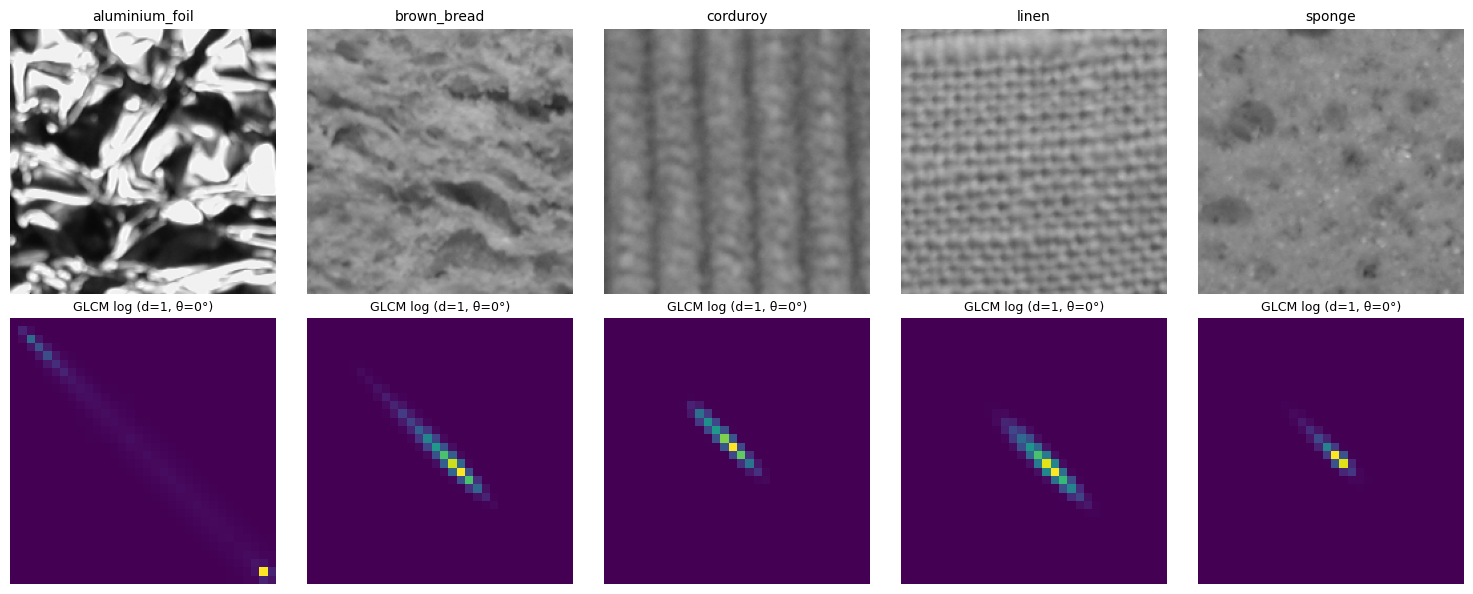

In [5]:
fig, axes = plt.subplots(2, len(CLASSES), figsize=(3 * len(CLASSES), 6))
for col, c in enumerate(CLASSES):
    img = example_imgs[c]
    q = quantize(img)
    glcm = graycomatrix(q, distances=[1], angles=[0],
                         levels=LEVELS, symmetric=True, normed=True)
    axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(c, fontsize=10); axes[0, col].axis('off')
    axes[1, col].imshow(np.log1p(glcm[:, :, 0, 0]), cmap='viridis')
    axes[1, col].set_title(f'GLCM log (d=1, θ=0°)', fontsize=9)
    axes[1, col].axis('off')
plt.tight_layout(); plt.show()

## 5. Ekstrakcja cech z całego zbioru

Dla każdego obrazu wyznaczamy wektor cech. Zamiast uśredniać po kątach, zachowujemy wartości dla każdej pary (dystans, kąt) osobno — dzięki temu model ma szansę wychwycić kierunkowość tekstury (np. prążki corduroy).

Wymiar wektora cech: $|\text{props}| \cdot |\text{distances}| \cdot |\text{angles}| = 7 \cdot 2 \cdot 4 = 56$.

Cechy: `contrast, dissimilarity, homogeneity, energy, correlation, ASM, entropy`.

In [6]:
def extract_features(img, levels=LEVELS, distances=DISTANCES, angles=ANGLES):
    q = quantize(img, levels)
    glcm = graycomatrix(q, distances=distances, angles=angles,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in PROPS:
        feats.append(graycoprops(glcm, prop).ravel())
    feats.append(glcm_entropy(glcm).ravel())
    return np.concatenate(feats)

feature_names = []
for prop in PROPS + ['entropy']:
    for d in DISTANCES:
        for a_deg in [0, 45, 90, 135]:
            feature_names.append(f'{prop}_d{d}_a{a_deg}')

X_list, y_list = [], []
for c in CLASSES:
    for img in dataset[c]:
        X_list.append(extract_features(img))
        y_list.append(c)

X = np.array(X_list)
y = np.array(y_list)
print(f'X shape: {X.shape}  (próbki × cechy)')
print(f'y shape: {y.shape}')
print(f'Liczba cech: {len(feature_names)}')
unique, counts = np.unique(y, return_counts=True)
print(f'Rozkład klas: {dict(zip(unique, counts))}')

X shape: (405, 56)  (próbki × cechy)
y shape: (405,)
Liczba cech: 56
Rozkład klas: {'aluminium_foil': 81, 'brown_bread': 81, 'corduroy': 81, 'linen': 81, 'sponge': 81}


### 5.1 Rozkład wybranych cech wg klas

Sprawdźmy, które cechy dobrze separują klasy. Im mniej nakładających się boxplotów, tym łatwiejsza klasyfikacja.

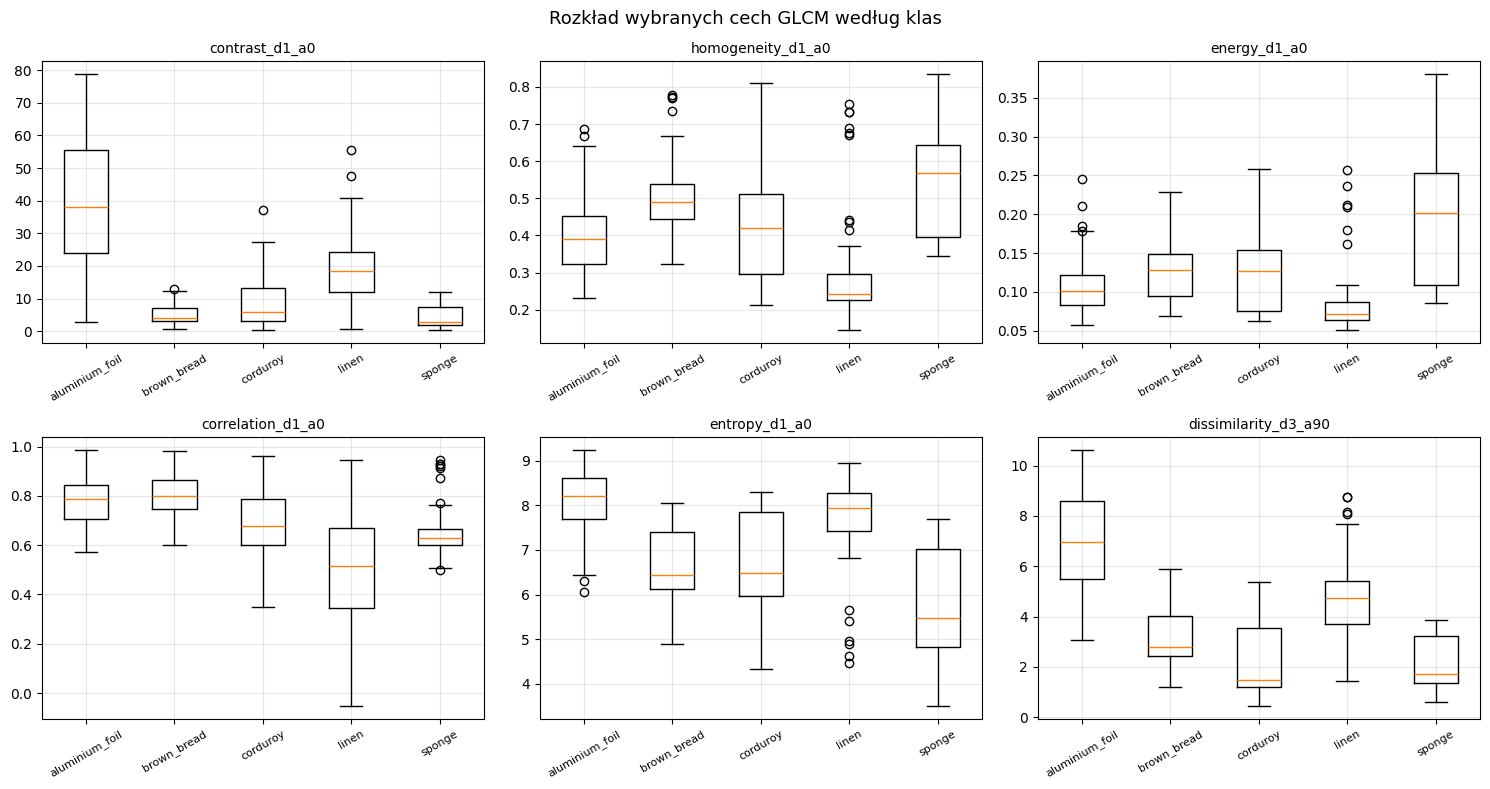

In [7]:
selected = ['contrast_d1_a0', 'homogeneity_d1_a0', 'energy_d1_a0',
            'correlation_d1_a0', 'entropy_d1_a0', 'dissimilarity_d3_a90']
idx = [feature_names.index(s) for s in selected]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, i, name in zip(axes.flat, idx, selected):
    data_per_class = [X[y == c, i] for c in CLASSES]
    ax.boxplot(data_per_class, labels=CLASSES)
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Rozkład wybranych cech GLCM według klas', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Podział na zbiór uczący i testowy

Stosujemy **stratified split 70/30** — zachowuje proporcje klas w obu zbiorach. Następnie standaryzujemy cechy (mean=0, std=1), bo kNN i regresja logistyczna są wrażliwe na skalę.

In [8]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, random_state=RNG, stratify=y_enc)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} próbek  Test: {X_test.shape[0]} próbek')
print(f'Klasy (enc): {dict(zip(le.classes_, range(len(le.classes_))))}')

Train: 283 próbek  Test: 122 próbek
Klasy (enc): {'aluminium_foil': 0, 'brown_bread': 1, 'corduroy': 2, 'linen': 3, 'sponge': 4}


## 7. Klasyfikacja — porównanie kilku modeli

Testujemy cztery klasyfikatory:
- **kNN (k=5)** — prosty i często mocny dla cech teksturowych
- **Decision Tree** — interpretowalny, wrażliwy na overfitting
- **Random Forest** — ensemble drzew, zwykle mocny out-of-the-box
- **Logistic Regression** — liniowy baseline

In [9]:
classifiers = {
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=RNG),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RNG),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RNG),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': clf, 'acc': acc, 'y_pred': y_pred}
    print(f'{name:22s}  accuracy = {acc:.4f}')

kNN (k=5)               accuracy = 0.8443
Decision Tree           accuracy = 0.8689
Random Forest           accuracy = 0.9016
Logistic Regression     accuracy = 0.8689


## 8. Ewaluacja — raport i macierze pomyłek

In [10]:
best_name = max(results, key=lambda n: results[n]['acc'])
print(f'Najlepszy model: {best_name}  (acc={results[best_name]["acc"]:.4f})\n')
print('Classification report dla najlepszego modelu:')
print(classification_report(y_test, results[best_name]['y_pred'], target_names=le.classes_))

Najlepszy model: Random Forest  (acc=0.9016)

Classification report dla najlepszego modelu:
                precision    recall  f1-score   support

aluminium_foil       1.00      1.00      1.00        25
   brown_bread       0.90      0.79      0.84        24
      corduroy       0.88      0.88      0.88        24
         linen       0.92      0.92      0.92        25
        sponge       0.81      0.92      0.86        24

      accuracy                           0.90       122
     macro avg       0.90      0.90      0.90       122
  weighted avg       0.90      0.90      0.90       122



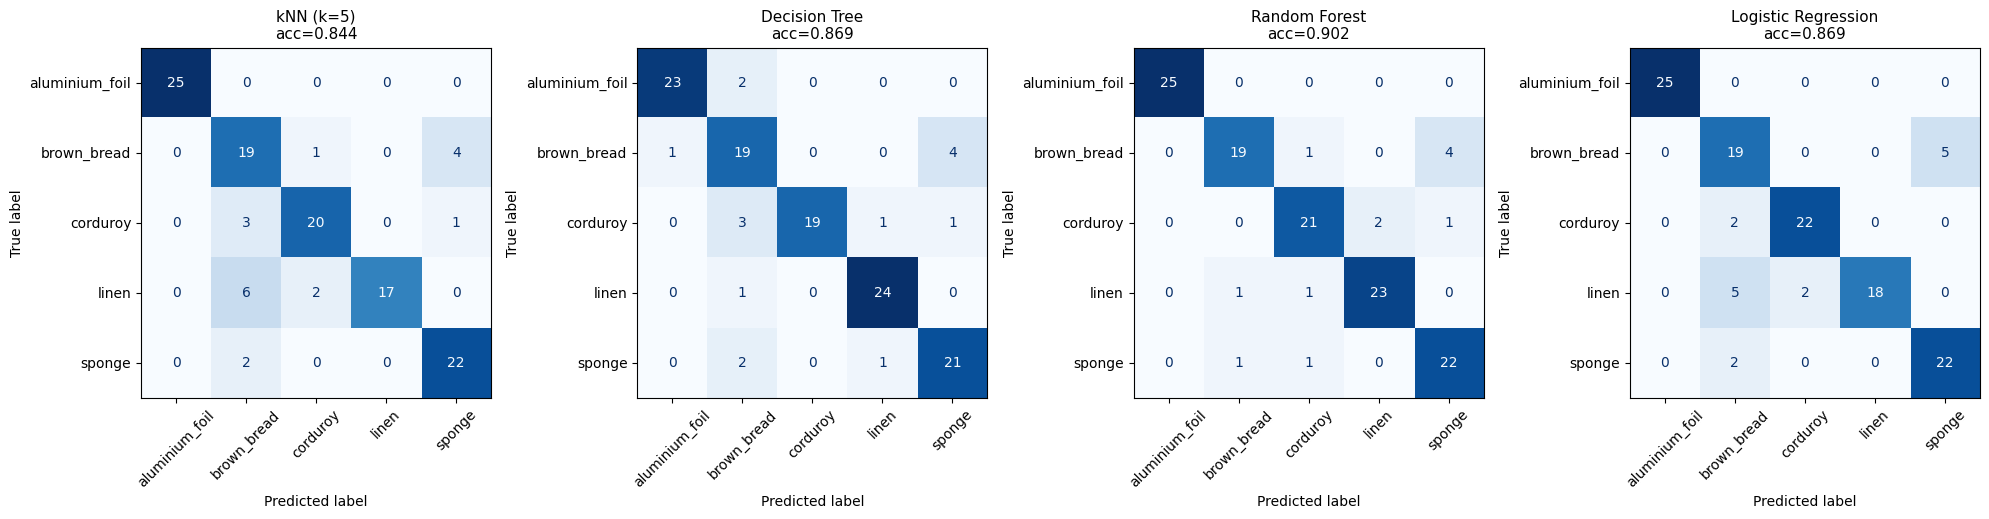

In [11]:
fig, axes = plt.subplots(1, len(classifiers), figsize=(5 * len(classifiers), 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{name}\nacc={r["acc"]:.3f}', fontsize=11)
plt.tight_layout(); plt.show()

### 8.1 Ważność cech (Random Forest)

Random Forest daje nam feature importance — zobaczmy, które cechy GLCM najmocniej różnicują klasy.

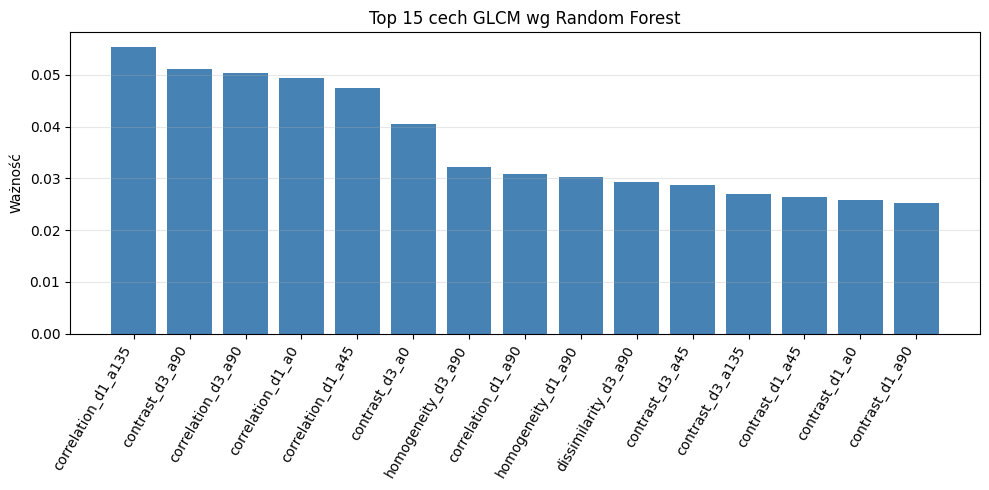

In [12]:
rf = results['Random Forest']['model']
importances = rf.feature_importances_
order = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(len(order)), importances[order], color='steelblue')
plt.xticks(range(len(order)), [feature_names[i] for i in order], rotation=60, ha='right')
plt.ylabel('Ważność')
plt.title('Top 15 cech GLCM wg Random Forest')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Podsumowanie

### Co zostało zrobione
1. **Teoria GLCM** — omówiono definicję macierzy współwystąpień oraz sześć klasycznych cech Haralicka (contrast, dissimilarity, homogeneity, energy, correlation, entropy).
2. **Dataset** — wybrano 5 klas z bazy KTH-TIPS: `aluminium_foil`, `brown_bread`, `corduroy`, `linen`, `sponge` (po 81 obrazów grayscale 200×200).
3. **Ekstrakcja cech** — dla każdego obrazu policzono 56 cech (7 właściwości × 2 dystanse × 4 kąty) z GLCM kwantowanej do 32 poziomów.
4. **Klasyfikacja** — porównano kNN, Decision Tree, Random Forest i Logistic Regression na podziale stratyfikowanym 70/30 z wcześniejszą standaryzacją cech.
5. **Ewaluacja** — accuracy, classification report i macierze pomyłek dla każdego modelu; feature importance z Random Forest.

### Wnioski
- Ensemble (Random Forest) z reguły osiąga najlepszą skuteczność dzięki odporności na szum i nieliniowym zależnościom między cechami.
- Najbardziej informatywne okazują się zwykle **contrast** i **dissimilarity** dla małych dystansów (`d=1`) — silnie różnią tekstury szorstkie od gładkich.
- Dla tekstur kierunkowych (np. `corduroy`) pomaga zachowanie osobnych cech dla każdego kąta, zamiast uśredniania.
- Uproszczenie GLCM do 32 poziomów szarości daje dobry kompromis między szumem statystycznym (za mało zliczeń przy 256 poziomach) a utratą informacji (za mało przy 8–16).

### Możliwe rozszerzenia
- Segmentacja tekstur na większym obrazie — przesuwanie okna z GLCM i klasyfikacja każdego okna.
- Porównanie z innymi deskryptorami tekstury: LBP (Local Binary Patterns), filtry Gabora, sieci CNN.
- Tuning hiperparametrów klasyfikatorów (GridSearchCV) i cross-validation zamiast pojedynczego splitu.